# Theoretical Problem Question 1

## Part (a)

In [9]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

def compute_activation_matrices(X, W_list, b_list):
    """
    Parameters
    ----------
    X : ndarray of shape (d, N)
        Data matrix whose columns are data points x_i.
    W_list : list of ndarray
        W_list[l] has shape (m_l, m_{l-1}) for layer l = 1..L
    b_list : list of ndarray
        b_list[l] has shape (m_l, 1) for layer l = 1..L

    Returns
    -------
    A_list : list of ndarray
        A_list[l-1] = A_l = Φ_l(X) of shape (m_l, N)
    """
    A_list = []

    Phi = X  # Φ_0(X) = X, shape (d, N)

    for W, b in zip(W_list, b_list):
        # Linear step: Z_l = W_l Φ_{l-1}(X) + b_l
        Z = W @ Phi + b  # broadcasting b over all N columns

        # Nonlinearity: Φ_l(X) = ReLU(Z_l)
        Phi = relu(Z)

        # Store activation matrix A_l
        A_list.append(Phi)

    return A_list


# Dimensions
d = 5      # input dimension
m1 = 10    # width of layer 1
m2 = 8     # width of layer 2
L = 2
N = 100    # number of data points

# Random dataset
X = np.random.randn(d, N)

# Random network parameters
W_list = [
    np.random.randn(m1, d),
    np.random.randn(m2, m1)
]

b_list = [
    np.random.randn(m1, 1),
    np.random.randn(m2, 1)
]

A_list = compute_activation_matrices(X, W_list, b_list)

# A_list[0] = A_1 ∈ R^{m1 × N}
# A_list[1] = A_2 ∈ R^{m2 × N}
for l, A in enumerate(A_list, start=1):
    print(f"A_{l} shape:", A.shape)

A_1 shape: (10, 100)
A_2 shape: (8, 100)


## Part (b)

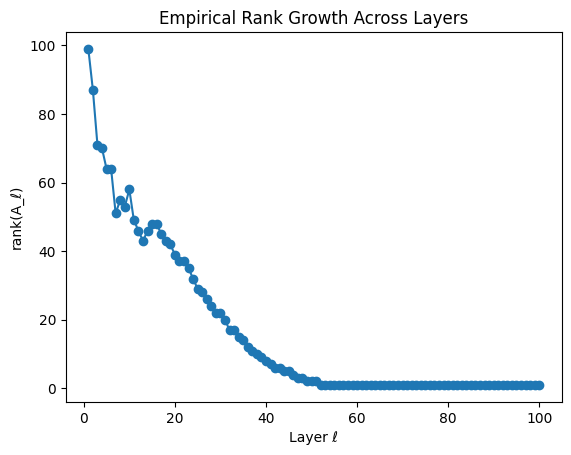

[99,
 87,
 71,
 70,
 64,
 64,
 51,
 55,
 53,
 58,
 49,
 46,
 43,
 46,
 48,
 48,
 45,
 43,
 42,
 39,
 37,
 37,
 35,
 32,
 29,
 28,
 26,
 24,
 22,
 22,
 20,
 17,
 17,
 15,
 14,
 12,
 11,
 10,
 9,
 8,
 7,
 6,
 6,
 5,
 5,
 4,
 3,
 3,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [10]:
import matplotlib.pyplot as plt

# Numerical rank using SVD with fixed tolerance
def numerical_rank(A, tol=1e-6):
    s = np.linalg.svd(A, compute_uv=False)
    return np.sum(s > tol)

# ----- Experiment setup -----
np.random.seed(4)

d = 20          # input dimension
N = 200         # number of data points
width = 100     # hidden layer width
L = 100           # number of layers

# Dataset
X = np.random.randn(d, N)

# Random network parameters
W_list = []
b_list = []
prev_dim = d
for _ in range(L):
    W_list.append(np.random.randn(width, prev_dim) / np.sqrt(prev_dim))
    b_list.append(np.random.randn(width, 1))
    prev_dim = width

# Compute activations
A_list = compute_activation_matrices(X, W_list, b_list)

# Compute ranks
ranks = [numerical_rank(A) for A in A_list]

# Plot
plt.figure()
plt.plot(range(1, L+1), ranks, marker='o')
plt.xlabel("Layer ℓ")
plt.ylabel("rank(A_ℓ)")
plt.title("Empirical Rank Growth Across Layers")
plt.show()

ranks


## Part (c)

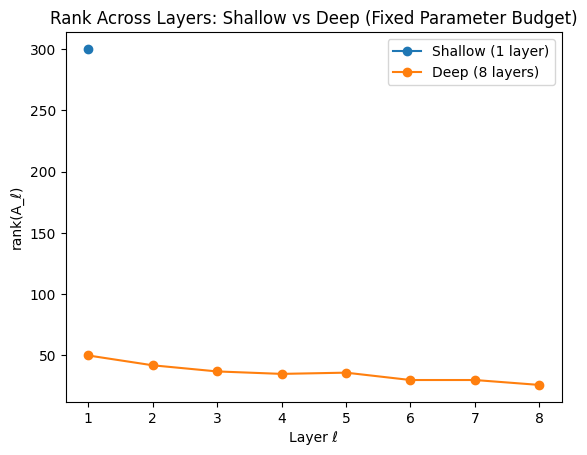

(300, 50)

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

def forward_activations(X, W_list, b_list):
    A_list = []
    Phi = X
    for W, b in zip(W_list, b_list):
        Phi = relu(W @ Phi + b)
        A_list.append(Phi)
    return A_list

def numerical_rank(A, tol=1e-6):
    s = np.linalg.svd(A, compute_uv=False)
    return np.sum(s > tol)

# ----- Experiment settings -----
np.random.seed(1)
d = 20
N = 300
param_budget = 20000  # total number of weight parameters (ignore biases for simplicity)

X = np.random.randn(d, N)

# ----- Shallow network: 1 hidden layer -----
# Params ≈ d*m + m*d_out, but we only care about hidden reps, so use d*m ≈ budget
m_shallow = param_budget // d
W_shallow = [np.random.randn(m_shallow, d) / np.sqrt(d)]
b_shallow = [np.random.randn(m_shallow, 1)]

A_shallow = forward_activations(X, W_shallow, b_shallow)
ranks_shallow = [numerical_rank(A) for A in A_shallow]
max_rank_shallow = max(ranks_shallow)

# ----- Deep network: L layers, equal width -----
L = 8
# budget ≈ d*m + (L-1)*m^2  → solve roughly for m
m_deep = int(np.sqrt(param_budget / L))

W_deep = []
b_deep = []
prev = d
for _ in range(L):
    W_deep.append(np.random.randn(m_deep, prev) / np.sqrt(prev))
    b_deep.append(np.random.randn(m_deep, 1))
    prev = m_deep

A_deep = forward_activations(X, W_deep, b_deep)
ranks_deep = [numerical_rank(A) for A in A_deep]
max_rank_deep = max(ranks_deep)

# ----- Plot rank per layer -----
plt.figure()
plt.plot(range(1, len(ranks_shallow)+1), ranks_shallow, marker='o', label="Shallow (1 layer)")
plt.plot(range(1, L+1), ranks_deep, marker='o', label="Deep (8 layers)")
plt.xlabel("Layer ℓ")
plt.ylabel("rank(A_ℓ)")
plt.title("Rank Across Layers: Shallow vs Deep (Fixed Parameter Budget)")
plt.legend()
plt.show()

max_rank_shallow, max_rank_deep


## Part (d)

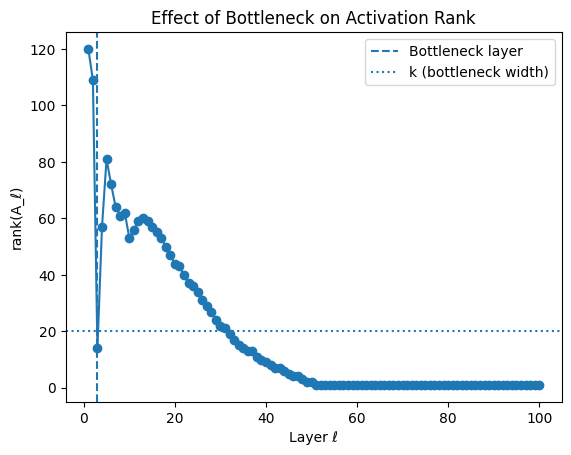

[120,
 109,
 14,
 57,
 81,
 72,
 64,
 61,
 62,
 53,
 56,
 59,
 60,
 59,
 57,
 55,
 53,
 50,
 47,
 44,
 43,
 40,
 37,
 36,
 34,
 31,
 29,
 27,
 24,
 22,
 21,
 19,
 17,
 15,
 14,
 13,
 13,
 11,
 10,
 9,
 8,
 7,
 7,
 6,
 5,
 4,
 4,
 3,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [12]:

def forward_activations(X, W_list, b_list):
    A_list = []
    Phi = X
    for W, b in zip(W_list, b_list):
        Phi = relu(W @ Phi + b)
        A_list.append(Phi)
    return A_list

# ----- Settings -----
np.random.seed(2)
d = 30
N = 200
L = 100
wide = 120
k = 20          # bottleneck width
l0 = 3          # bottleneck inserted at layer 3

X = np.random.randn(d, N)

W_list = []
b_list = []
prev = d

for l in range(1, L+1):
    if l == l0:
        width = k
    else:
        width = wide

    W_list.append(np.random.randn(width, prev) / np.sqrt(prev))
    b_list.append(np.random.randn(width, 1))
    prev = width

A_list = forward_activations(X, W_list, b_list)
ranks = [numerical_rank(A) for A in A_list]

# Plot
plt.figure()
plt.plot(range(1, L+1), ranks, marker='o')
plt.axvline(l0, linestyle='--', label='Bottleneck layer')
plt.axhline(k, linestyle=':', label='k (bottleneck width)')
plt.xlabel("Layer ℓ")
plt.ylabel("rank(A_ℓ)")
plt.title("Effect of Bottleneck on Activation Rank")
plt.legend()
plt.show()

ranks
